In [ ]:
import nltk

import os
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# from textblob import TextBlob
from pathlib import Path
from nltk.tokenize import sent_tokenize
from nltk.tokenize import word_tokenize
from tqdm import tqdm
import matplotlib.ticker as ticker
import re
from sklearn.model_selection import train_test_split
import torch.nn.functional as F
import torch
from nltk.corpus import stopwords

import torch
import torch.nn as nn
from torch.utils.data import Dataset
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import seaborn as sns
from transformers import AutoModel, AutoTokenizer
from torch.optim import AdamW
from transformers.optimization import get_linear_schedule_with_warmup
from sklearn.metrics import classification_report

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix

def evaluate_model(model, data_loader, criterion, device, num_classes=4):
    model.eval()
    metrics = {'loss': 0, 'correct': 0, 'total': 0, 'all_preds': [], 'all_labels': []}

    with torch.no_grad():
        for batch in data_loader:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['labels'].to(device)

            outputs = model(input_ids=input_ids, attention_mask=attention_mask)
            loss = criterion(outputs, labels)

            metrics['loss'] += loss.item() * labels.size(0)
            preds = outputs.argmax(dim=1)
            metrics['correct'] += (preds == labels).sum().item()
            metrics['total'] += labels.size(0)

            metrics['all_preds'].extend(preds.cpu().numpy())
            metrics['all_labels'].extend(labels.cpu().numpy())

    metrics['loss'] /= metrics['total']
    metrics['acc'] = metrics['correct'] / metrics['total']
    report = classification_report(metrics['all_labels'], metrics['all_preds'], output_dict=True, zero_division=0)
    metrics['f1'] = report['macro avg']['f1-score']
    metrics['conf_matrix'] = confusion_matrix(metrics['all_labels'], metrics['all_preds'], labels=list(range(num_classes)))

    return metrics



def train_model(model, train_loader, val_loader, optimizer, scheduler, device,
                patience=15, epochs=100, num_classes=4):

    criterion = nn.CrossEntropyLoss()
    best_val_loss = float('inf')
    epochs_no_improve = 0

    history = {
        'train_loss': [], 'train_acc': [], 'train_f1': [],
        'val_loss': [], 'val_acc': [], 'val_f1': [],
        'confusion_matrices': []
    }

    for epoch in range(epochs):
        print("This is the epoch number", epoch)
        model.train()
        train_metrics = {'loss': 0, 'correct': 0, 'total': 0, 'all_preds': [], 'all_labels': []}

        for batch in train_loader:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['labels'].to(device)

            optimizer.zero_grad() # what about this
            outputs = model(input_ids=input_ids, attention_mask=attention_mask)
            loss = criterion(outputs, labels)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            scheduler.step()

            train_metrics['loss'] += loss.item() * labels.size(0)
            preds = outputs.argmax(dim=1)
            train_metrics['correct'] += (preds == labels).sum().item()
            train_metrics['total'] += labels.size(0)
            train_metrics['all_preds'].extend(preds.cpu().numpy())
            train_metrics['all_labels'].extend(labels.cpu().numpy())

        train_loss = train_metrics['loss'] / train_metrics['total']
        train_acc = train_metrics['correct'] / train_metrics['total']
        train_f1 = classification_report(train_metrics['all_labels'], train_metrics['all_preds'],
                                         output_dict=True, zero_division=0)['macro avg']['f1-score']

        val_metrics = evaluate_model(model, val_loader, criterion, device, num_classes)

        # Save to history
        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['train_f1'].append(train_f1)
        history['val_loss'].append(val_metrics['loss'])
        history['val_acc'].append(val_metrics['acc'])
        history['val_f1'].append(val_metrics['f1'])
        history['confusion_matrices'].append(val_metrics['conf_matrix'])

        print(f"Epoch {epoch+1}:")
        print(f"Train  - Loss: {train_loss:.4f}, Acc: {train_acc:.4f}, F1: {train_f1:.4f}")
        print(f"Val    - Loss: {val_metrics['loss']:.4f}, Acc: {val_metrics['acc']:.4f}, F1: {val_metrics['f1']:.4f}")
        print("-" * 50)

        if val_metrics['loss'] < best_val_loss:
            best_val_loss = val_metrics['loss']
            torch.save(model.state_dict(), 'best_model.pth')
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1
            if epochs_no_improve >= patience:
                print(f"Early stopping at epoch {epoch+1}")
                break

    model.load_state_dict(torch.load('best_model.pth'))
    return model, history



In [ ]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)


Mounted at /content/drive


In [ ]:
def plot_training_history(history, method = None, lr = None):
    plt.figure(figsize=(12, 5))

    # Loss plot
    plt.subplot(1, 2, 1)
    plt.plot(history['train_loss'], label='Train Loss')
    plt.plot(history['val_loss'], label='Validation Loss')
    plt.title('Training and Validation Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    drive_folder = Path("/content/drive/MyDrive/NLP_BDS_1")
    plot_path = drive_folder / f"loss_word2vec_{method}_&_{lr}.png"
    plt.savefig(plot_path)
    plt.legend()

    # Accuracy plot
    plt.subplot(1, 2, 2)
    plt.plot(history['train_acc'], label='Train Accuracy')
    plt.plot(history['val_acc'], label='Validation Accuracy')
    plt.title('Training and Validation Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()
    drive_folder = Path("/content/drive/MyDrive/NLP_BDS_1")
    plot_path = drive_folder / f"acc_word2vec_{method}_&_{lr}.png"
    plt.savefig(plot_path)
    plt.tight_layout()
    #plt.show()

    # F1-score plot
    plt.figure(figsize=(6, 4))
    plt.plot(history['train_f1'], label='Train F1')
    plt.plot(history['val_f1'], label='Validation F1')
    plt.title('Training and Validation F1 Score')
    plt.xlabel('Epoch')
    plt.ylabel('F1 Score')
    plt.legend()
    drive_folder = Path("/content/drive/MyDrive/NLP_BDS_1")
    plot_path = drive_folder / f"f1_word2vec_{method}_&_{lr}.png"
    plt.savefig(plot_path)
    #plt.show()

def plot_confusion_matrix(cm, classes, method = None, lr = None):
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=classes, yticklabels=classes)
    plt.title('Confusion Matrix')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.tight_layout()
    drive_folder = Path("/content/drive/MyDrive/NLP_BDS_1")
    plot_path = drive_folder / f"final_model_confusion_matrix_{method}_&_{lr}.png"
    plt.savefig(plot_path)
    #plt.show()

In [ ]:
def set_seed(seed=42):
    import random, torch, numpy as np
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)


In [ ]:
# Load ClimateBERT
model_name = "Climatebert/distilroberta-base-climate-f"
base_model = AutoModel.from_pretrained(model_name)
tokenizer = AutoTokenizer.from_pretrained(model_name)
#model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=4,output_attentions = False, output_hidden_states = False)


/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(
Some weights of RobertaModel were not initialized from the model checkpoint at Climatebert/distilroberta-base-climate-f and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [ ]:
drive_folder = Path("/content/drive/MyDrive/NLP_BDS_1")
PATH = drive_folder / "DF_bert_embeddings.csv"
df = pd.read_csv(PATH)
df_1 = df.drop(['climate_sentences_extended', 'contains_climate_keyword', 'matched_climate_keywords', 'speeches_for_keyword_search', 'Year', 'ISO-Code', 'count_climate_change'], axis = 1)

df_1['Income Level Encoded'] = df_1['Income Level'] - 1

df_1 = df_1.drop(['Income Level'], axis = 1)

df_1

,final_text,Income Level Encoded
0,the conference must produce results that will ...,0
1,looking forward into the 1990s we see a world ...,0
2,an increase in the planet's average temperatur...,0
3,i congratulate you sir on your election as pre...,3
4,international treaties in specific fields of t...,3
...,...,...
2941,excellencies i extend my congratulations to hi...,1
2942,for this reason the republic of yemen renews i...,0
2943,president of the 79th session of the un genera...,2
2944,ladies and gentlemen i congratulate you your e...,1


In [ ]:
class ClimateDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_length=512):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = str(self.texts[idx])
        label = self.labels[idx]

        encoding = self.tokenizer.encode_plus(
            text,
            add_special_tokens=True,
            max_length=self.max_length,
            padding='max_length',
            truncation=True,
            return_attention_mask=True,
            return_tensors='pt'
        )

        return {
            'input_ids': encoding['input_ids'].flatten(),
            'attention_mask': encoding['attention_mask'].flatten(),
            'labels': torch.tensor(label, dtype=torch.long)
        }

# First split: 87.5% train+val, 12.5% test (unchanged)
X_trainval, X_test, y_trainval, y_test = train_test_split(
    df_1['final_text'].tolist(),
    df_1['Income Level Encoded'].tolist(),
    test_size=0.2,
    random_state=42,
    stratify=df_1['Income Level Encoded']
)

# Second split: 80% train, 20% validation (of the remaining 80%)
X_train, X_val, y_train, y_val = train_test_split(
    X_trainval,
    y_trainval,
    test_size=0.25,
    random_state=42,
    stratify=y_trainval
)

train_dataset = ClimateDataset(X_train, y_train, tokenizer)
val_dataset = ClimateDataset(X_val, y_val, tokenizer)
test_dataset = ClimateDataset(X_test, y_test, tokenizer)

# DataLoaders
train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=8)
test_loader = DataLoader(test_dataset, batch_size=8)

In [ ]:
import torch
import torch.nn as nn

class ClimateBERTClassifier(nn.Module):
    def __init__(self, base_model, num_classes=4):
        super(ClimateBERTClassifier, self).__init__()
        self.base_model = base_model
        self.dropout = nn.Dropout(0.1)
        self.classifier = nn.Linear(base_model.config.hidden_size, num_classes)

    def forward(self, input_ids, attention_mask):
        outputs = self.base_model(input_ids=input_ids,
                                attention_mask=attention_mask)
        pooled_output = outputs.last_hidden_state[:, 0, :]  # [CLS] token
        pooled_output = self.dropout(pooled_output)
        logits = self.classifier(pooled_output)
        return logits

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# Re-initialize base model and classifier
# Re-initialize base model and classifier
model = ClimateBERTClassifier(base_model).to(device)

# Correct reference to the model used
# Freeze all layers first
for param in model.base_model.parameters():
    param.requires_grad = False

# Unfreeze classifier
for param in model.classifier.parameters():
    param.requires_grad = True

# Unfreeze the last layer of the base model
for layer in list(base_model.encoder.layer)[-1:]:
  for param in layer.parameters():
    param.requires_grad = True

# After one training step, check gradients
for name, param in model.named_parameters():
    if name.startswith("base_model.encoder.layer.4.") or name.startswith("base_model.encoder.layer.5.") or name.startswith("classifier"):
        print(f"{'Trainable' if param.requires_grad else 'Frozen'}: {name}")


Frozen: base_model.encoder.layer.4.attention.self.query.weight
Frozen: base_model.encoder.layer.4.attention.self.query.bias
Frozen: base_model.encoder.layer.4.attention.self.key.weight
Frozen: base_model.encoder.layer.4.attention.self.key.bias
Frozen: base_model.encoder.layer.4.attention.self.value.weight
Frozen: base_model.encoder.layer.4.attention.self.value.bias
Frozen: base_model.encoder.layer.4.attention.output.dense.weight
Frozen: base_model.encoder.layer.4.attention.output.dense.bias
Frozen: base_model.encoder.layer.4.attention.output.LayerNorm.weight
Frozen: base_model.encoder.layer.4.attention.output.LayerNorm.bias
Frozen: base_model.encoder.layer.4.intermediate.dense.weight
Frozen: base_model.encoder.layer.4.intermediate.dense.bias
Frozen: base_model.encoder.layer.4.output.dense.weight
Frozen: base_model.encoder.layer.4.output.dense.bias
Frozen: base_model.encoder.layer.4.output.LayerNorm.weight
Frozen: base_model.encoder.layer.4.output.LayerNorm.bias
Trainable: base_model.en


========== Starting run with LR: 0.001 ==========

This is the epoch number 0
Epoch 1:
Train  - Loss: 1.3396, Acc: 0.3283, F1: 0.2671
Val    - Loss: 1.2813, Acc: 0.3797, F1: 0.2668
--------------------------------------------------
This is the epoch number 1
Epoch 2:
Train  - Loss: 1.2359, Acc: 0.4277, F1: 0.3968
Val    - Loss: 1.2010, Acc: 0.4549, F1: 0.4338
--------------------------------------------------
This is the epoch number 2
Epoch 3:
Train  - Loss: 1.1605, Acc: 0.4784, F1: 0.4566
Val    - Loss: 1.1154, Acc: 0.4962, F1: 0.4933
--------------------------------------------------
This is the epoch number 3
Epoch 4:
Train  - Loss: 1.0804, Acc: 0.5300, F1: 0.5137
Val    - Loss: 1.0577, Acc: 0.5338, F1: 0.5163
--------------------------------------------------
This is the epoch number 4
Epoch 5:
Train  - Loss: 1.0128, Acc: 0.5723, F1: 0.5578
Val    - Loss: 1.0355, Acc: 0.5489, F1: 0.5474
--------------------------------------------------
This is the epoch number 5
Epoch 6:
Train  

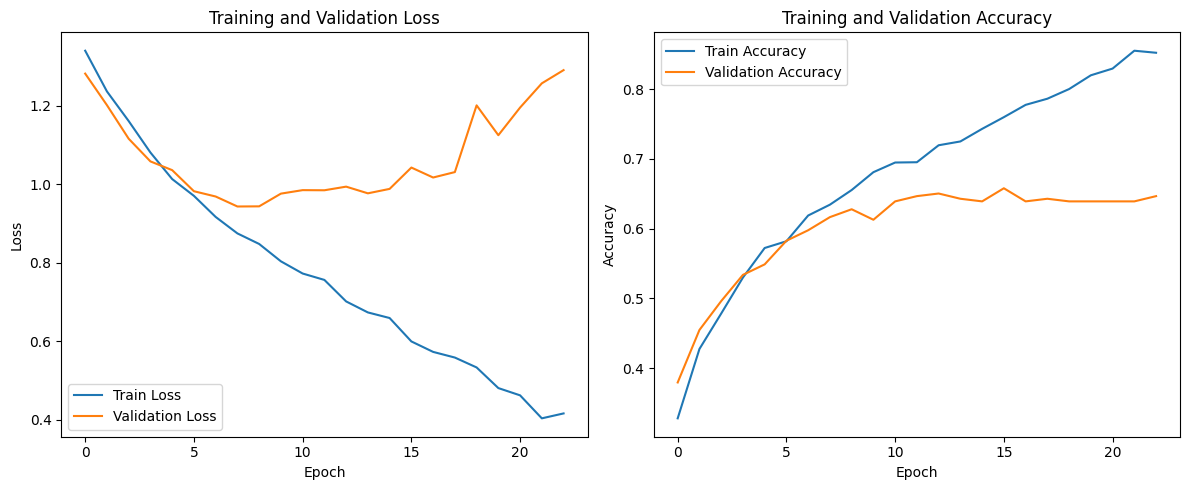

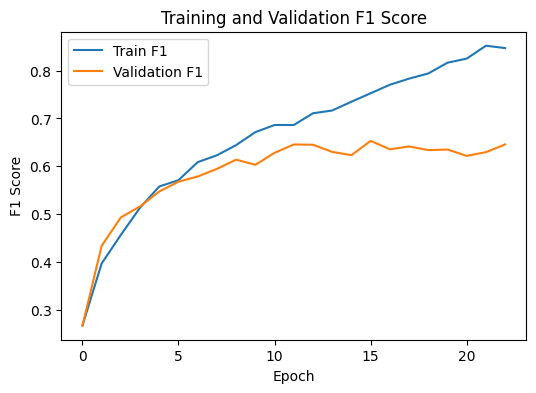

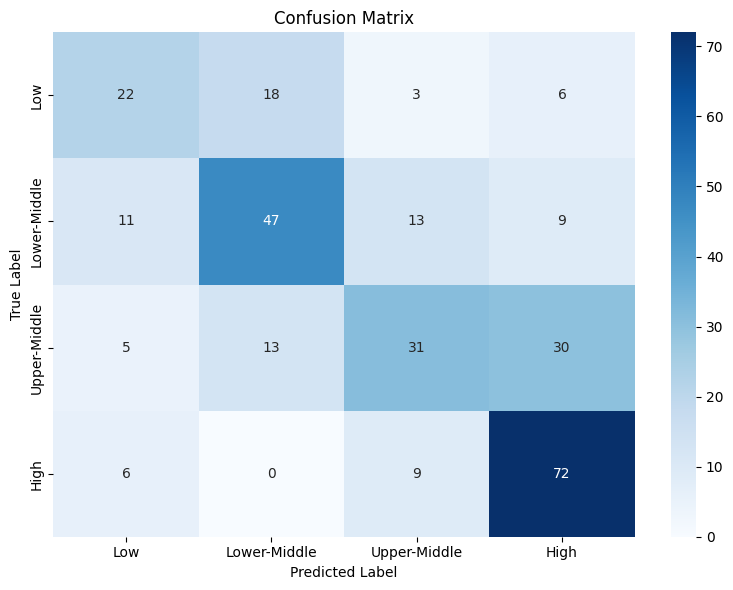

In [ ]:
learning_rates = [1e-3]
num_epochs = 100

results = []

for learning_rate in learning_rates:
    print(f"\n========== Starting run with LR: {learning_rate} ==========\n")

    # Reset seed and clear cache
    set_seed(42)
    torch.cuda.empty_cache()
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    # Reinitialize model
    model = ClimateBERTClassifier(base_model).to(device)

    # Freeze all layers
    for param in model.base_model.parameters():
        param.requires_grad = False

    # Unfreeze the last layer of the base model
    for layer in list(base_model.encoder.layer)[-1:]:
      for param in layer.parameters():
        param.requires_grad = True

    # Unfreeze classifier
    for param in model.classifier.parameters():
        param.requires_grad = True

    optimizer = AdamW([
        {'params': model.base_model.encoder.layer[-1:].parameters(), 'lr': 2e-5},
        {'params': model.classifier.parameters(), 'lr': learning_rate}
    ])

    scheduler = get_linear_schedule_with_warmup(
        optimizer,
        num_warmup_steps=0,
        num_training_steps=len(train_loader) * num_epochs
    )

    trained_model, history = train_model(
        model=model,
        train_loader=train_loader,
        val_loader=val_loader,
        optimizer=optimizer,
        scheduler=scheduler,
        device=device,
        patience=15,
        epochs=num_epochs,
        num_classes=4
    )

    plot_training_history(history, method="ClimateBERT", lr=learning_rate)


    test_metrics = evaluate_model(
        model=trained_model,
        data_loader=test_loader,
        criterion=nn.CrossEntropyLoss(),
        device=device,
        num_classes=4
    )

    class_names = ["Low", "Lower-Middle", "Upper-Middle", "High"]
    plot_confusion_matrix(test_metrics['conf_matrix'], classes=class_names, method="ClimateBERT", lr=learning_rate)

    # 5. Print final results
    print("\n" + "="*50)
    print("FINAL TEST RESULTS")
    print(f"Test Loss: {test_metrics['loss']:.4f}")
    print(f"Test Accuracy: {test_metrics['acc']:.4f}")
    print(f"Test F1: {test_metrics['f1']:.4f}")
    # The classification report is not stored in the dictionary, so we call the function again to print it.
    print("\nClassification Report:")
    print(classification_report(test_metrics['all_labels'], test_metrics['all_preds'], zero_division=0))
    print("="*50 + "\n")
    test_f1 = test_metrics['f1']
    results.append((learning_rate, test_f1))

# Store all results
results_df = pd.DataFrame(results, columns=["LearningRate","TestF1"])
results_df = results_df.sort_values("TestF1", ascending=False)
# Save to CSV
results_df.to_csv(drive_folder / "results_grid_search_1.csv", index=False)

In [ ]:
results_df

,LearningRate,TestF1
0,0.001,0.558299



========== Starting run with LR: 0.0003 ==========

This is the epoch number 0
Epoch 1:
Train  - Loss: 0.9442, Acc: 0.5971, F1: 0.5824
Val    - Loss: 0.9195, Acc: 0.6165, F1: 0.5954
--------------------------------------------------
This is the epoch number 1
Epoch 2:
Train  - Loss: 0.8366, Acc: 0.6667, F1: 0.6587
Val    - Loss: 0.9221, Acc: 0.6278, F1: 0.6175
--------------------------------------------------
This is the epoch number 2
Epoch 3:
Train  - Loss: 0.8008, Acc: 0.6725, F1: 0.6606
Val    - Loss: 0.9042, Acc: 0.6429, F1: 0.6362
--------------------------------------------------
This is the epoch number 3
Epoch 4:
Train  - Loss: 0.7417, Acc: 0.7061, F1: 0.6972
Val    - Loss: 0.8926, Acc: 0.6466, F1: 0.6308
--------------------------------------------------
This is the epoch number 4
Epoch 5:
Train  - Loss: 0.7075, Acc: 0.7291, F1: 0.7201
Val    - Loss: 1.0053, Acc: 0.6466, F1: 0.6412
--------------------------------------------------
This is the epoch number 5
Epoch 6:
Train 

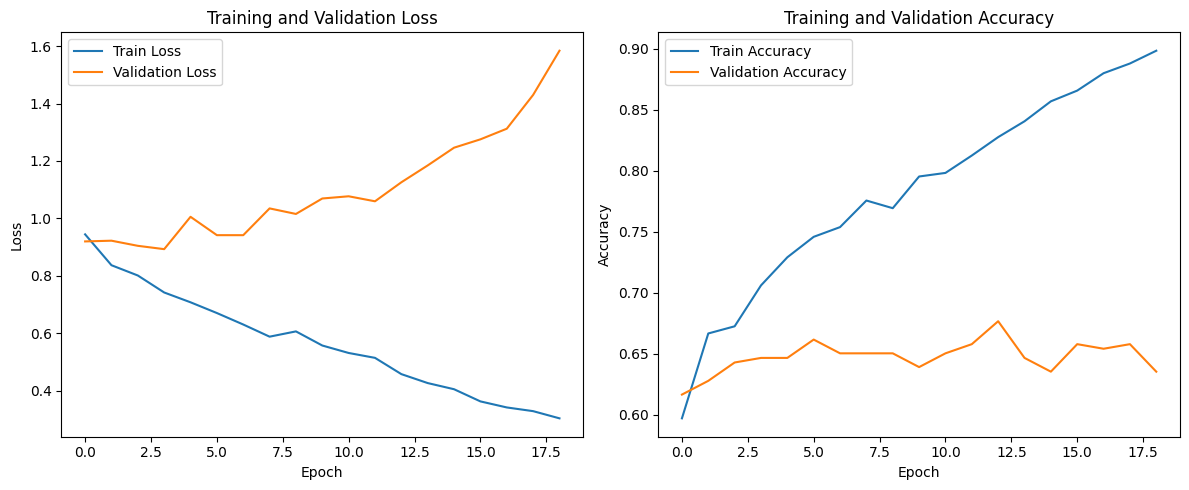

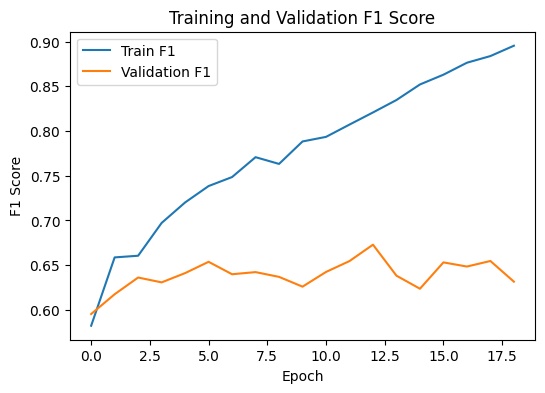

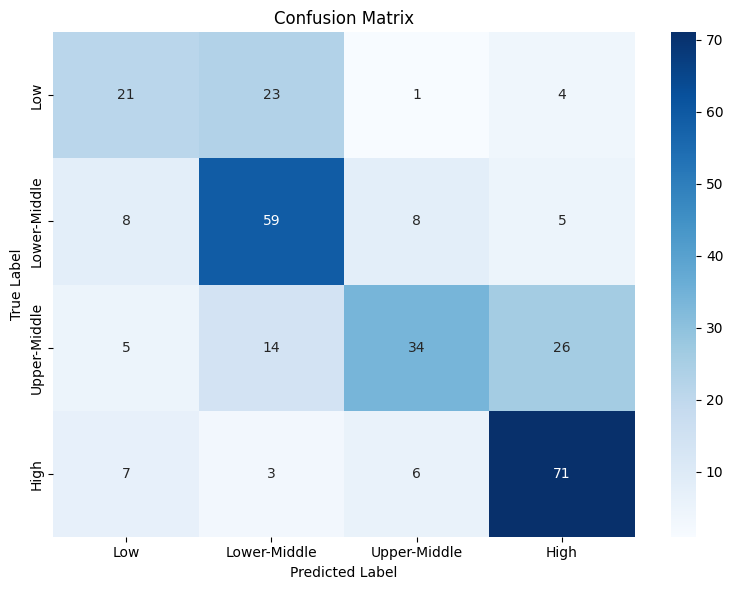

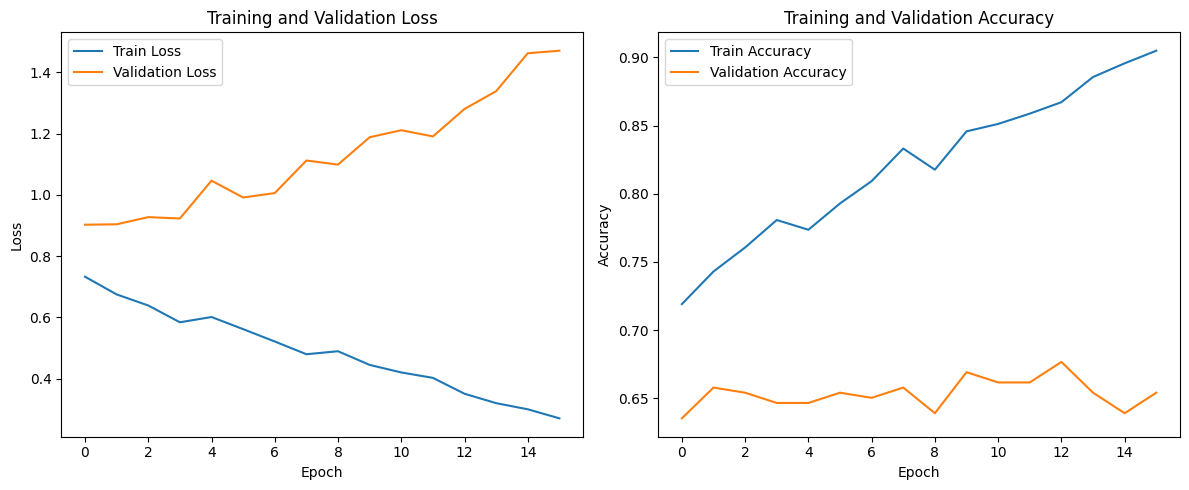

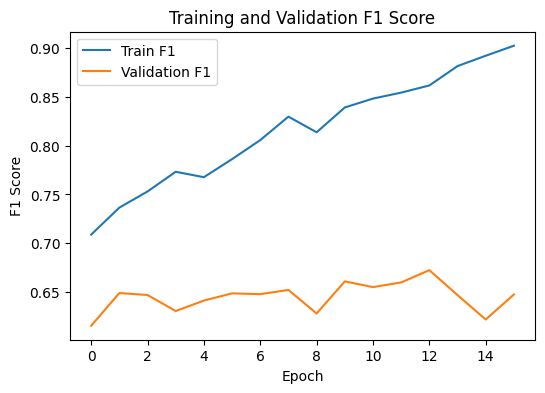

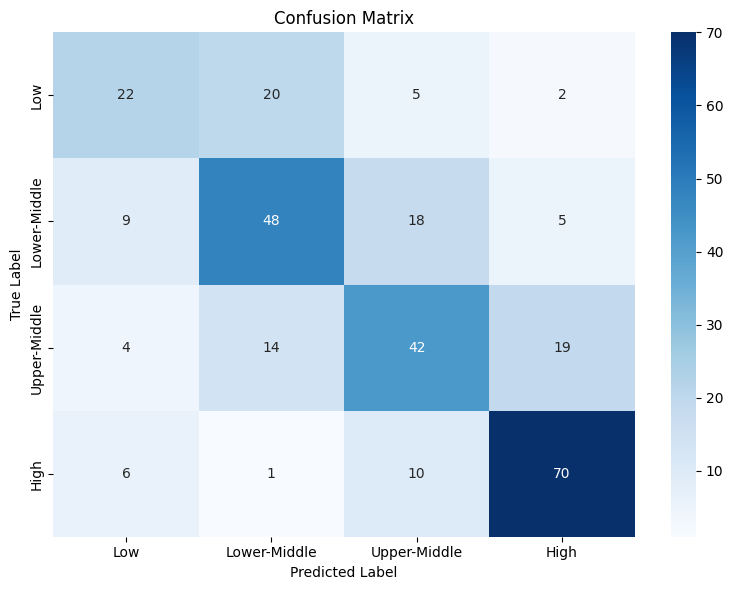

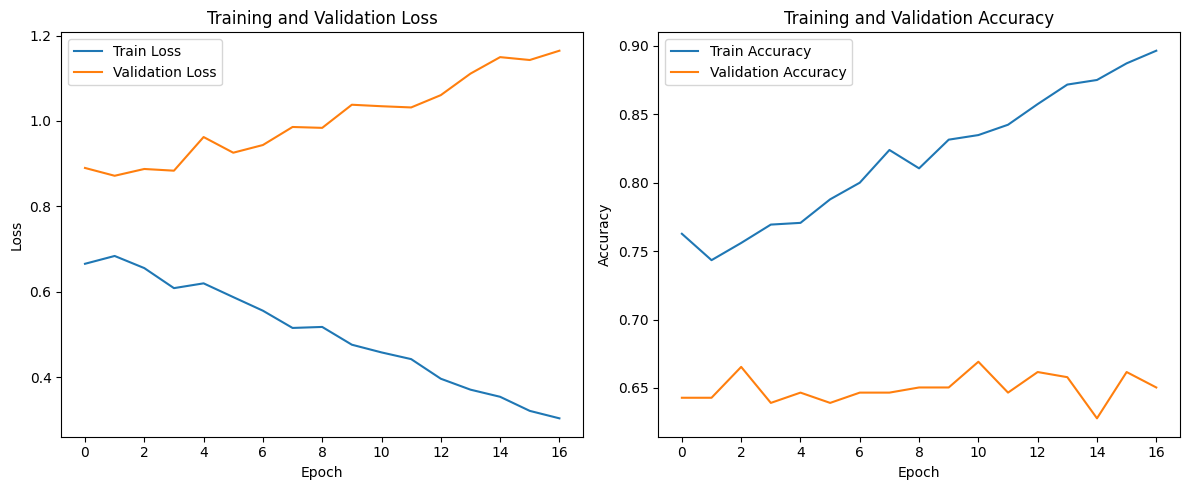

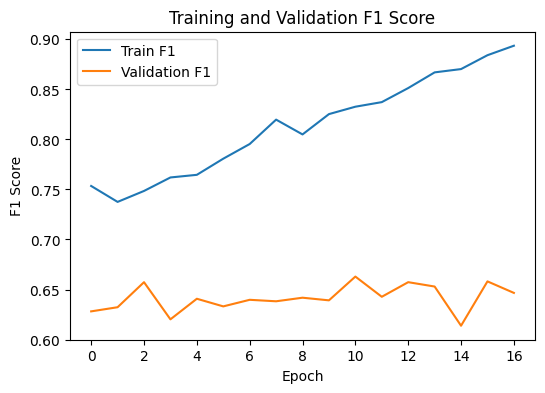

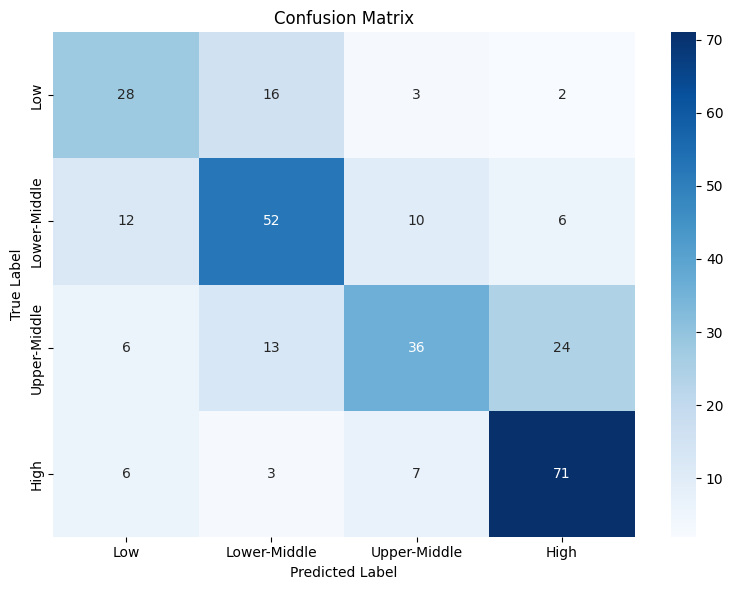

In [ ]:
learning_rates = [3e-4, 2e-4, 1e-5]
num_epochs = 100

results = []

for learning_rate in learning_rates:
    print(f"\n========== Starting run with LR: {learning_rate} ==========\n")

    # Reset seed and clear cache
    set_seed(42)
    torch.cuda.empty_cache()
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    # Reinitialize model
    model = ClimateBERTClassifier(base_model).to(device)

    # Freeze all layers
    for param in model.base_model.parameters():
        param.requires_grad = False

    # Unfreeze the last layer of the base model
    for layer in list(base_model.encoder.layer)[-1:]:
      for param in layer.parameters():
        param.requires_grad = True

    # Unfreeze classifier
    for param in model.classifier.parameters():
        param.requires_grad = True

    optimizer = AdamW([
        {'params': model.base_model.encoder.layer[-1:].parameters(), 'lr': 2e-5},
        {'params': model.classifier.parameters(), 'lr': learning_rate}
    ])

    scheduler = get_linear_schedule_with_warmup(
        optimizer,
        num_warmup_steps=0,
        num_training_steps=len(train_loader) * num_epochs
    )

    trained_model, history = train_model(
        model=model,
        train_loader=train_loader,
        val_loader=val_loader,
        optimizer=optimizer,
        scheduler=scheduler,
        device=device,
        patience=15,
        epochs=num_epochs,
        num_classes=4
    )

    plot_training_history(history, method="ClimateBERT", lr=learning_rate)


    test_metrics = evaluate_model(
        model=trained_model,
        data_loader=test_loader,
        criterion=nn.CrossEntropyLoss(),
        device=device,
        num_classes=4
    )

    class_names = ["Low", "Lower-Middle", "Upper-Middle", "High"]
    plot_confusion_matrix(test_metrics['conf_matrix'], classes=class_names, method="ClimateBERT", lr=learning_rate)

    # 5. Print final results
    print("\n" + "="*50)
    print("FINAL TEST RESULTS")
    print(f"Test Loss: {test_metrics['loss']:.4f}")
    print(f"Test Accuracy: {test_metrics['acc']:.4f}")
    print(f"Test F1: {test_metrics['f1']:.4f}")
    # The classification report is not stored in the dictionary, so we call the function again to print it.
    print("\nClassification Report:")
    print(classification_report(test_metrics['all_labels'], test_metrics['all_preds'], zero_division=0))
    print("="*50 + "\n")
    test_f1 = test_metrics['f1']
    results.append((learning_rate, test_f1))

# Store all results
results_df = pd.DataFrame(results, columns=["LearningRate","TestF1"])
results_df = results_df.sort_values("TestF1", ascending=False)
# Save to CSV
results_df.to_csv(drive_folder / "results_grid_search_2.csv", index=False)

In [ ]:
results_df

,LearningRate,TestF1
2,0.00001,0.617326
0,0.00030,0.598221
1,0.00020,0.597082
